# Individual Household Electric Power Consumption

The main objective of this Exploratory Data Analysis (EDA) project is to examine household
electricity usage patterns to derive meaningful insights, detect inefficiencies, and enhance
energy management

# Problem Statement:

Electricity consumption in households fluctuates throughout the day and across various
appliances. Gaining a clear understanding of these patterns is essential for optimizing energy
efficiency, lowering expenses, and promoting sustainable power usage. However, many
households lack detailed information on their electricity consumption, the appliances that
contribute most to their energy use, and the effects of voltage fluctuations on overall power
consumption.


 Importing the necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

# Data Ingestion 

In [2]:
df = pd.read_csv('household_power_consumption.csv')

# Basic Data Understanding

1. What is the total number of records in the dataset?

In [12]:
print("Total number of records:", len(df))

Total number of records: 1048575


2. Are there any missing values in the dataset? If so, in which columns?


In [9]:
df.isnull().sum()

Date                        0
Time                        0
Global_active_power         0
Global_reactive_power       0
Voltage                     0
Global_intensity            0
Sub_metering_1              0
Sub_metering_2              0
Sub_metering_3           4069
dtype: int64

3. What are the data types of each column?

In [10]:
df.dtypes

Date                         str
Time                         str
Global_active_power          str
Global_reactive_power        str
Voltage                      str
Global_intensity             str
Sub_metering_1               str
Sub_metering_2               str
Sub_metering_3           float64
dtype: object

4. What is the range of dates present in the dataset?

In [11]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

print("Start Date:", df['Date'].min())
print("End Date:", df['Date'].max())

Start Date: 2006-12-16 00:00:00
End Date: 2008-12-13 00:00:00


# Descriptive Statistics

5. First you have to make a Total_Submetering column by adding the all submeterings.


In [12]:
# Convert sub-metering columns to numeric
cols = ['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

# Create Total_Submetering column
df['Total_Submetering'] = df[cols].sum(axis=1)

# Display result
df[['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'Total_Submetering']].head()

,Sub_metering_1,Sub_metering_2,Sub_metering_3,Total_Submetering
0,0.0,1.0,17.0,18.0
1,0.0,1.0,16.0,17.0
2,0.0,2.0,17.0,19.0
3,0.0,1.0,17.0,18.0
4,0.0,1.0,17.0,18.0


In [13]:
df['Sub_metering_3'] = df['Sub_metering_3'].astype(str)

In [14]:
df['Sub_metering_3'].dtype

<StringDtype(na_value=nan)>

In [17]:
df['Sub_metering_3'] = df['Sub_metering_3'].astype('float64')

In [18]:
df.dtypes

Date                     datetime64[us]
Time                                str
Global_active_power                 str
Global_reactive_power               str
Voltage                             str
Global_intensity                    str
Sub_metering_1                  float64
Sub_metering_2                  float64
Sub_metering_3                  float64
Total_Submetering               float64
dtype: object

In [21]:
df['Total_Submetering'] = (
    df['Sub_metering_1'] +
    df['Sub_metering_2'] +
    df['Sub_metering_3']
)

In [23]:
df

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Total_Submetering
0,2006-12-16,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,18.0
1,2006-12-16,17:25:00,5.36,0.436,233.63,23,0.0,1.0,16.0,17.0
2,2006-12-16,17:26:00,5.374,0.498,233.29,23,0.0,2.0,17.0,19.0
3,2006-12-16,17:27:00,5.388,0.502,233.74,23,0.0,1.0,17.0,18.0
4,2006-12-16,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,18.0
...,...,...,...,...,...,...,...,...,...,...
1048570,2008-12-13,21:34:00,0.426,0.076,242.27,1.8,0.0,0.0,0.0,0.0
1048571,2008-12-13,21:35:00,0.424,0.076,242.1,1.8,0.0,0.0,0.0,0.0
1048572,2008-12-13,21:36:00,0.422,0.076,241.73,1.8,0.0,0.0,0.0,0.0
1048573,2008-12-13,21:37:00,0.422,0.078,242.56,1.8,0.0,0.0,0.0,0.0


6. What are the summary statistics (mean, median, min, max, standard deviation) for
global_active_power, global_reactive_power, voltage, and global_intensity?

In [24]:
cols = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity'
]

df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

df[cols].agg(['mean', 'median', 'min', 'max', 'std'])

,Global_active_power,Global_reactive_power,Voltage,Global_intensity
mean,1.108202,0.118273,239.959803,4.718123
median,0.550000,0.098000,240.210000,2.400000
min,0.076000,0.000000,223.490000,0.200000
max,10.670000,1.390000,252.140000,46.400000
std,1.129546,0.109506,3.284504,4.763588


7. What is the mean and standard deviation of the Total_Submetering column?

In [25]:
df['Total_Submetering'].mean()

np.float64(8.586464797712987)

In [26]:
df['Total_Submetering'].std()

np.float64(13.255753450851522)

8. What is the distribution of voltage in the dataset? (e.g., histogram or KDE plot)

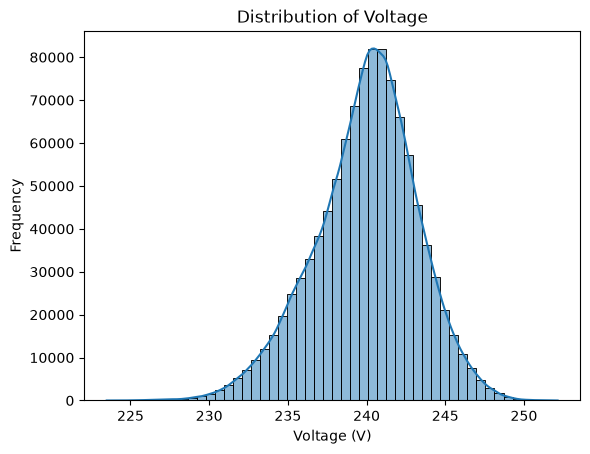

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt


df['Voltage'] = pd.to_numeric(df['Voltage'], errors='coerce')


sns.histplot(df['Voltage'], bins=50, kde=True)

plt.title('Distribution of Voltage')
plt.xlabel('Voltage (V)')
plt.ylabel('Frequency')
plt.show()

9. What is the correlation between global_active_power and global_intensity?


In [29]:

df['Global_active_power'] = pd.to_numeric(
    df['Global_active_power'], errors='coerce'
)
df['Global_intensity'] = pd.to_numeric(
    df['Global_intensity'], errors='coerce'
)


correlation = df['Global_active_power'].corr(df['Global_intensity'])

print("Correlation:", correlation)

Correlation: 0.9990196001620193


10. How does global_active_power vary with voltage?

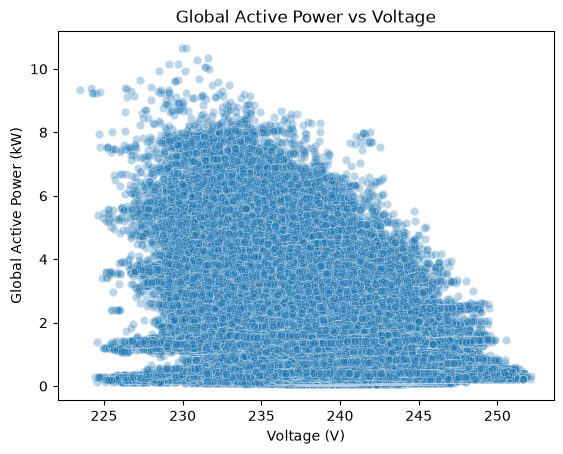

In [5]:
# Convert columns to numeric
df['Global_active_power'] = pd.to_numeric(
    df['Global_active_power'], errors='coerce'
)

df['Voltage'] = pd.to_numeric(
    df['Voltage'], errors='coerce'
)

# Scatter plot
sns.scatterplot(
    data=df,
    x='Voltage',
    y='Global_active_power',
    alpha=0.3
)

plt.title('Global Active Power vs Voltage')
plt.xlabel('Voltage (V)')
plt.ylabel('Global Active Power (kW)')
plt.show()

11. What are the minimum and maximum values of global_active_power, and at what
times did they occur?

In [6]:
df['Global_active_power'] = pd.to_numeric(
    df['Global_active_power'], errors='coerce'
)

# Minimum value and its time
min_value = df['Global_active_power'].min()
min_rows = df[df['Global_active_power'] == min_value][['Date', 'Time']]

# Maximum value and its time
max_value = df['Global_active_power'].max()
max_rows = df[df['Global_active_power'] == max_value][['Date', 'Time']]

print("Minimum Global Active Power:", min_value)
print(min_rows)

print("\nMaximum Global Active Power:", max_value)
print(max_rows)

Minimum Global Active Power: 0.076
             Date      Time
871322  12/8/2008  19:26:00
894442  28/8/2008  20:46:00
894443  28/8/2008  20:47:00
894444  28/8/2008  20:48:00
894445  28/8/2008  20:49:00
894446  28/8/2008  20:50:00
894447  28/8/2008  20:51:00
894448  28/8/2008  20:52:00
894458  28/8/2008  21:02:00

Maximum Global Active Power: 10.67
            Date      Time
112450  4/3/2007  19:34:00


# Time-Based Analysis

11. How does global_active_power change over different hours of the day? (Hourly trend)

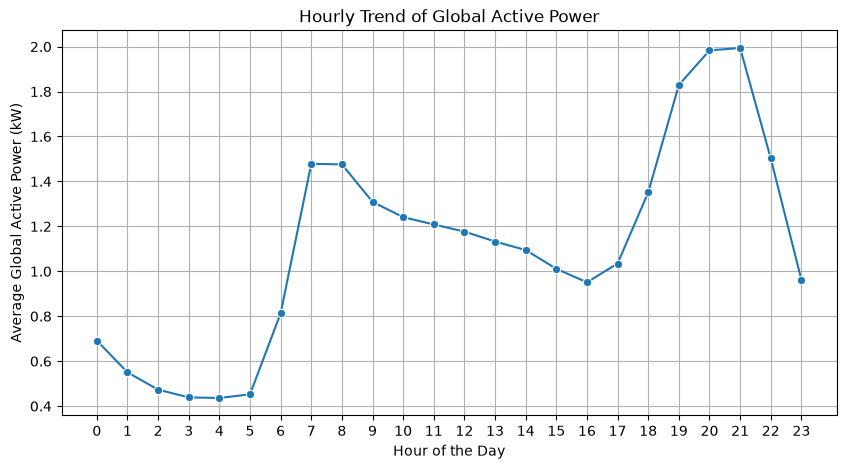

In [7]:
# Convert Global_active_power to numeric
df['Global_active_power'] = pd.to_numeric(
    df['Global_active_power'], errors='coerce'
)

# Extract hour from Time
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.hour

# Calculate average power for each hour
hourly_power = df.groupby('Hour')['Global_active_power'].mean()

# Plot hourly trend
plt.figure(figsize=(10, 5))
sns.lineplot(x=hourly_power.index, y=hourly_power.values, marker='o')

plt.title('Hourly Trend of Global Active Power')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Global Active Power (kW)')
plt.xticks(range(24))
plt.grid(True)
plt.show()

12. Are there any noticeable trends in power consumption over different days of the week?

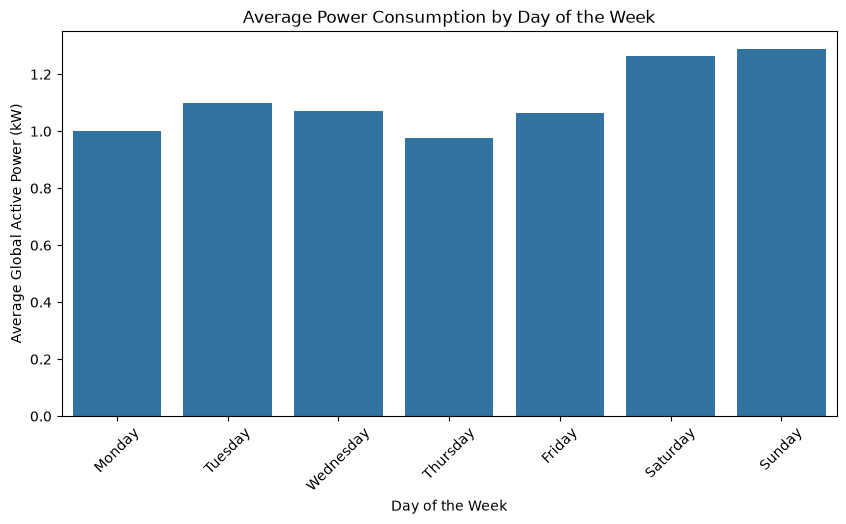

In [8]:
# Convert columns to proper data types
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Global_active_power'] = pd.to_numeric(
    df['Global_active_power'], errors='coerce'
)

# Extract day of the week
df['Day_of_Week'] = df['Date'].dt.day_name()

# Keep days in correct order
day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

# Calculate average power consumption
weekly_power = (
    df.groupby('Day_of_Week')['Global_active_power']
      .mean()
      .reindex(day_order)
)

# Plot
plt.figure(figsize=(10, 5))

sns.barplot(
    x=weekly_power.index,
    y=weekly_power.values
)

plt.title('Average Power Consumption by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Global Active Power (kW)')
plt.xticks(rotation=45)
plt.show()

13. How does Total_Submetering change over different hours of the day?

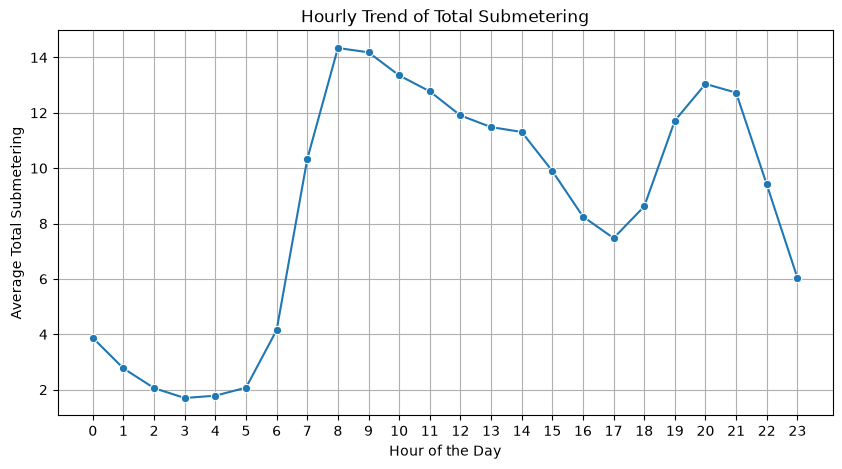

In [13]:
# Convert Total_Submetering to numeric
df['Total_Submetering'] = pd.to_numeric(
    df['Total_Submetering'], errors='coerce'
)

# Extract hour from Time
df['Hour'] = pd.to_datetime(
    df['Time'], format='%H:%M:%S'
).dt.hour

# Calculate average Total_Submetering for each hour
hourly_submetering = (
    df.groupby('Hour')['Total_Submetering']
      .mean()
)

# Plot hourly trend
plt.figure(figsize=(10, 5))

sns.lineplot(
    x=hourly_submetering.index,
    y=hourly_submetering.values,
    marker='o'
)

plt.title('Hourly Trend of Total Submetering')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Total Submetering')
plt.xticks(range(24))
plt.grid(True)
plt.show()

14. How does voltage fluctuate throughout a single day?

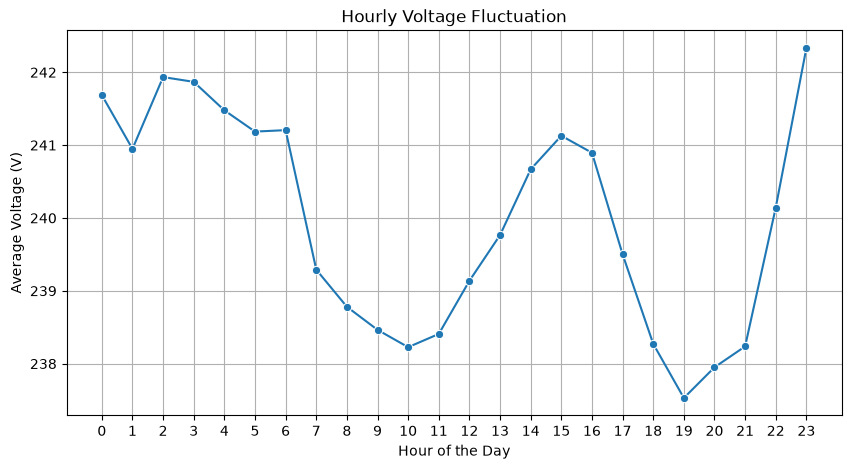

In [11]:
# Convert Voltage to numeric
df['Voltage'] = pd.to_numeric(df['Voltage'], errors='coerce')

# Extract hour from Time
df['Hour'] = pd.to_datetime(
    df['Time'], format='%H:%M:%S'
).dt.hour

# Calculate average voltage for each hour
hourly_voltage = (
    df.groupby('Hour')['Voltage']
      .mean()
)

# Plot hourly voltage fluctuation
plt.figure(figsize=(10, 5))

sns.lineplot(
    x=hourly_voltage.index,
    y=hourly_voltage.values,
    marker='o'
)

plt.title('Hourly Voltage Fluctuation')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Voltage (V)')
plt.xticks(range(24))
plt.grid(True)

plt.show()

15. What is the average global_active_power usage for each month?

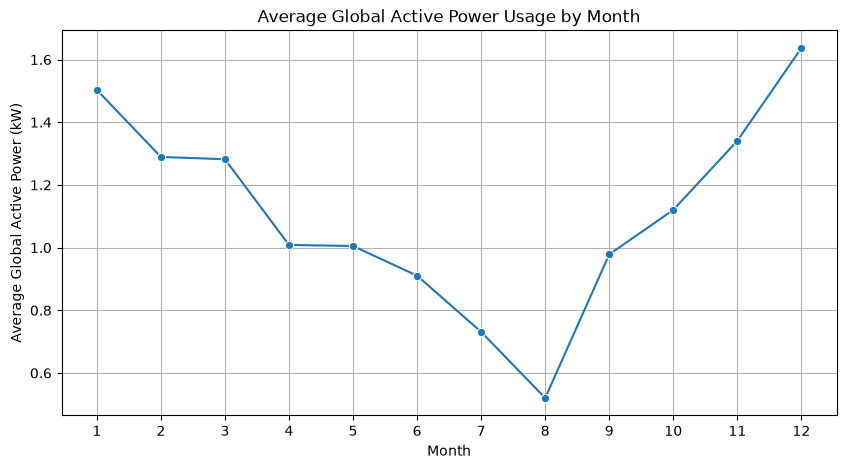

In [13]:
# Convert columns to proper data types
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df['Global_active_power'] = pd.to_numeric(
    df['Global_active_power'], errors='coerce'
)

# Extract month
df['Month'] = df['Date'].dt.month

# Calculate average global active power for each month
monthly_power = (
    df.groupby('Month')['Global_active_power']
      .mean()
)

# Plot
plt.figure(figsize=(10, 5))

sns.lineplot(
    x=monthly_power.index,
    y=monthly_power.values,
    marker='o'
)

plt.title('Average Global Active Power Usage by Month')
plt.xlabel('Month')
plt.ylabel('Average Global Active Power (kW)')
plt.xticks(range(1, 13))
plt.grid(True)

plt.show()

# Sub-Metering Analysis


16. Which sub-metering category (sub_metering_1, sub_metering_2, or sub_metering_3)
consumes the most power on average?

Sub_metering_3    5.933837
Sub_metering_2    1.475177
Sub_metering_1    1.177451
dtype: float64


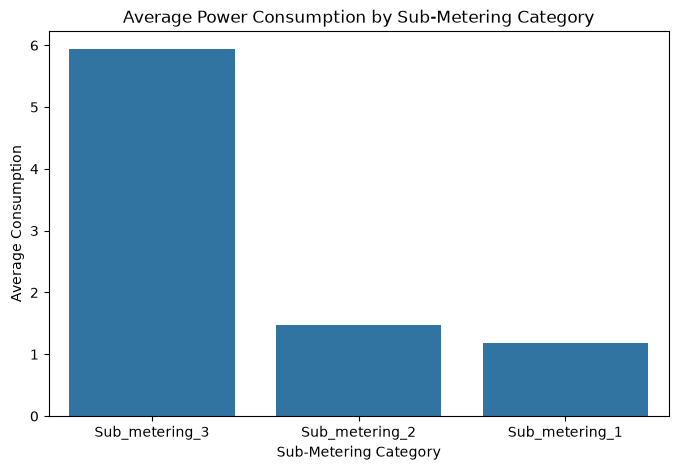

In [14]:
# Convert sub-metering columns to numeric
cols = ['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

# Calculate average consumption
average_submetering = df[cols].mean().sort_values(ascending=False)

print(average_submetering)

# Plot
plt.figure(figsize=(8, 5))

sns.barplot(
    x=average_submetering.index,
    y=average_submetering.values
)

plt.title('Average Power Consumption by Sub-Metering Category')
plt.xlabel('Sub-Metering Category')
plt.ylabel('Average Consumption')
plt.show()

17. How does Total_Submetering compare with global_active_power? Is there a strong
correlation?

Correlation: 0.8315145305268837


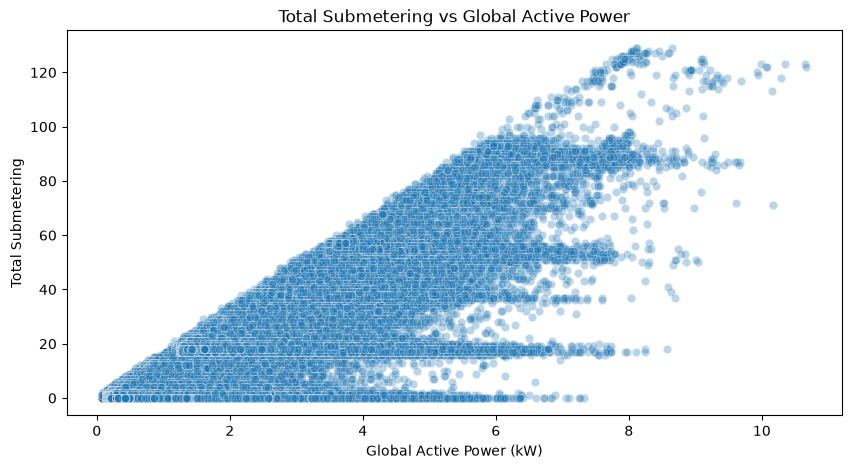

In [14]:
# Convert columns to numeric
df['Global_active_power'] = pd.to_numeric(
    df['Global_active_power'], errors='coerce'
)

df['Total_Submetering'] = pd.to_numeric(
    df['Total_Submetering'], errors='coerce'
)

# Calculate correlation
correlation = df['Total_Submetering'].corr(
    df['Global_active_power']
)

print("Correlation:", correlation)

# Scatter plot
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=df,
    x='Global_active_power',
    y='Total_Submetering',
    alpha=0.3
)

plt.title('Total Submetering vs Global Active Power')
plt.xlabel('Global Active Power (kW)')
plt.ylabel('Total Submetering')
plt.show()

18. How much energy is consumed outside of the three sub-metering categories
(global_active_power - Total_Submetering)?

Average Energy Outside Submetering: -7.478262629415245


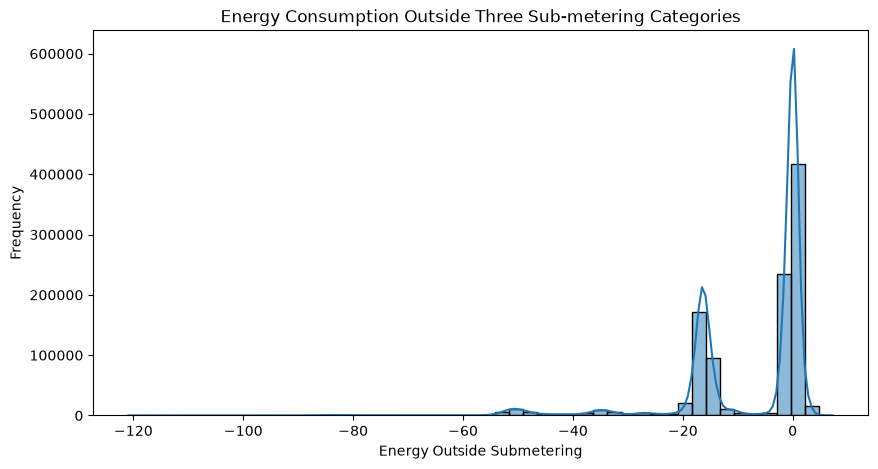

In [15]:
# Convert columns to numeric
df['Global_active_power'] = pd.to_numeric(
    df['Global_active_power'], errors='coerce'
)

df['Total_Submetering'] = pd.to_numeric(
    df['Total_Submetering'], errors='coerce'
)

# Calculate energy consumed outside the three sub-metering categories
df['Energy_Outside_Submetering'] = (
    df['Global_active_power'] - df['Total_Submetering']
)

# Display average energy consumed outside sub-metering
print(
    "Average Energy Outside Submetering:",
    df['Energy_Outside_Submetering'].mean()
)

# Plot distribution
plt.figure(figsize=(10, 5))

sns.histplot(
    df['Energy_Outside_Submetering'],
    bins=50,
    kde=True
)

plt.title('Energy Consumption Outside Three Sub-metering Categories')
plt.xlabel('Energy Outside Submetering')
plt.ylabel('Frequency')
plt.show()

In [16]:
df['Total_Submetering']

0          18.0
1          17.0
2          19.0
3          18.0
4          18.0
           ... 
1048570     0.0
1048571     0.0
1048572     0.0
1048573     0.0
1048574     0.0
Name: Total_Submetering, Length: 1048575, dtype: float64

In [3]:
df.head(1)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0,1,17.0


In [10]:
cols = [
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

df[cols] = df[cols].apply(
    pd.to_numeric,
    errors='coerce'
)

df['Total_Submetering'] = df[cols].sum(axis=1)

df.to_csv('household_power_consumption.csv', index=False)

In [11]:
df[['Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3',
    'Total_Submetering']].head()

,Sub_metering_1,Sub_metering_2,Sub_metering_3,Total_Submetering
0,0.0,1.0,17.0,18.0
1,0.0,1.0,16.0,17.0
2,0.0,2.0,17.0,19.0
3,0.0,1.0,17.0,18.0
4,0.0,1.0,17.0,18.0


In [12]:
df.head(2)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Total_Submetering
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,18.0
1,16/12/2006,17:25:00,5.36,0.436,233.63,23,0.0,1.0,16.0,17.0


19. Are there any specific time periods where Total_Submetering is significantly higher or
lower than usual?

Hour
0      3.870513
1      2.766392
2      2.055517
3      1.698214
4      1.781891
5      2.072161
6      4.152427
7     10.330563
8     14.341827
9     14.184753
10    13.351397
11    12.775046
12    11.905403
13    11.484409
14    11.307830
15     9.897711
16     8.251557
17     7.474037
18     8.617993
19    11.719250
20    13.044193
21    12.726824
22     9.411355
23     6.040774
Name: Total_Submetering, dtype: float64


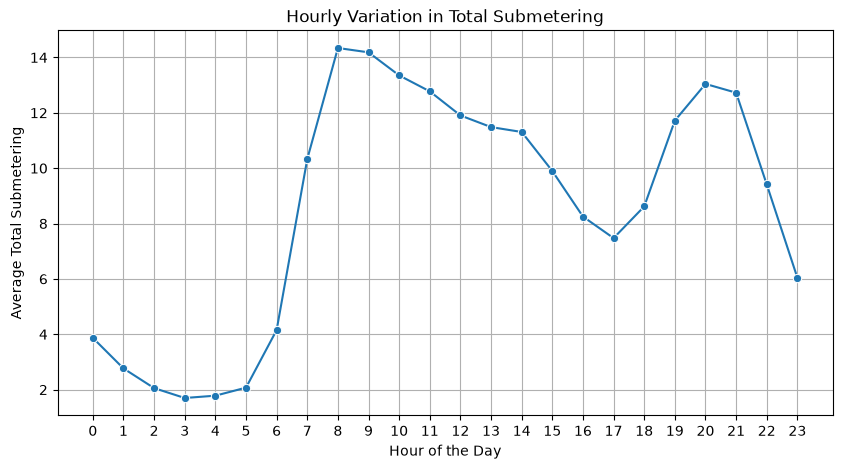

In [17]:
# Convert Time to datetime and extract hour
df['Hour'] = pd.to_datetime(
    df['Time'],
    format='%H:%M:%S'
).dt.hour

# Calculate average Total_Submetering for each hour
hourly_submetering = (
    df.groupby('Hour')['Total_Submetering']
      .mean()
)

# Display values
print(hourly_submetering)

# Plot
plt.figure(figsize=(10, 5))

sns.lineplot(
    x=hourly_submetering.index,
    y=hourly_submetering.values,
    marker='o'
)

plt.title('Hourly Variation in Total Submetering')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Total Submetering')
plt.xticks(range(24))
plt.grid(True)

plt.show()

20. Which hour of the day has the highest Total_Submetering on average?

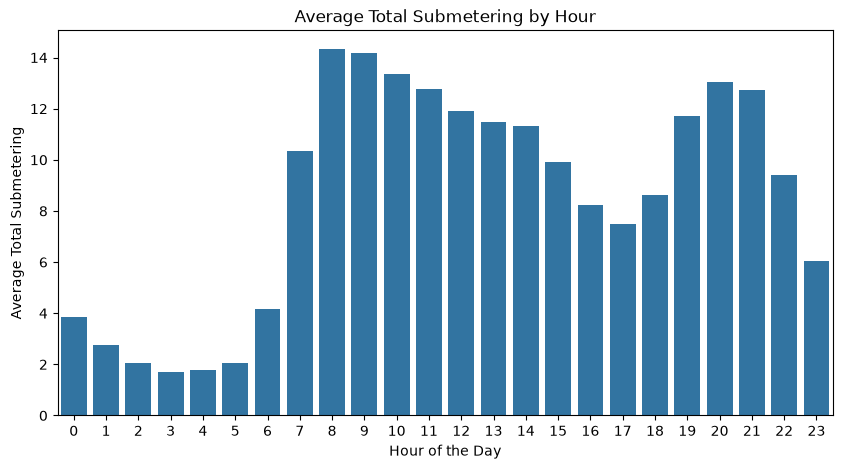

In [18]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=hourly_submetering.index,
    y=hourly_submetering.values
)

plt.title('Average Total Submetering by Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Total Submetering')
plt.xticks(range(24))
plt.show()